In [11]:
from paint.draw import *

#### Exp2025-Cifar10-Dir0.5

In [12]:
main_dir = '/home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5'
baseline_path_list = []
for algo_dir in sorted(os.listdir(main_dir),key=custom_sort):
    path = os.path.join(main_dir, algo_dir)
    if os.path.isdir(path):
        baseline_path_list.append(path)

for path in baseline_path_list:
    parse_log_file(path)
    print("finished " + path.split("/")[-1])




Data saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/FedAGSA-resnet-dir0.5-tg60-lm0.01-sorted/epoch_results.csv
finished FedAGSA-resnet-dir0.5-tg60-lm0.01-sorted
Data saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/PyramidFL-resnet-dir0.5/epoch_results.csv
finished PyramidFL-resnet-dir0.5
Data saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/FedDocs-resnet-dir0.5-alpha0.66/epoch_results.csv
finished FedDocs-resnet-dir0.5-alpha0.66
Data saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/TiFL-resnet-dir0.5/epoch_results.csv
finished TiFL-resnet-dir0.5
Data saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/FedAvg-resnet-dir0.5/epoch_results.csv
finished FedAvg-resnet-dir0.5


In [13]:
# 示例调用
delay_model_path = '/home/ypguo/async-FL/src/clients_info/resnet18/clients_info_dir0.5_resnet_delaymodel.csv'
# fedavg_epoch_result = '/home/ypguo/async-FL/src/results/Exp2025-Cifar10-lr0.5-Dir0.5/fedavg-cnn-dir0.5/epoch_results.csv'
for path in baseline_path_list:
    epoch_result_path = path + '/epoch_results.csv'
    output_csv_path = path + '/epoch_results_with_cumtime.csv'
    process_and_save_results(delay_model_path, epoch_result_path, output_csv_path)
    print("finished " + path.split("/")[-1])


Results saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/FedAGSA-resnet-dir0.5-tg60-lm0.01-sorted/epoch_results_with_cumtime.csv
finished FedAGSA-resnet-dir0.5-tg60-lm0.01-sorted
Results saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/PyramidFL-resnet-dir0.5/epoch_results_with_cumtime.csv
finished PyramidFL-resnet-dir0.5
Results saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/FedDocs-resnet-dir0.5-alpha0.66/epoch_results_with_cumtime.csv
finished FedDocs-resnet-dir0.5-alpha0.66
Results saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/TiFL-resnet-dir0.5/epoch_results_with_cumtime.csv
finished TiFL-resnet-dir0.5
Results saved to /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/FedAvg-resnet-dir0.5/epoch_results_with_cumtime.csv
finished FedAvg-resnet-dir0.5


In [14]:
import pandas as pd
import numpy as np
import os


# 使用示例
if __name__ == "__main__":
    # 准确率阈值列表
    accuracy_thresholds = [60,65,70]
    # 总轮次
    total_rounds = 300
    # 输出Excel文件路径
    output_excel_path = "federated_learning_results.xlsx"


    csv_paths_dict = {}
    
    for path in baseline_path_list:
        algo = path.split("/")[-1]
        algo_name = algo.split("-")[0]
        distribution = algo.split("-")[-1]
        
        # 确保正确的分布格式
        if distribution.lower() == "iid":
            dist_key = "IID"
        else:
            # 提取dir后的数字作为nonIID系数
            if distribution.lower().startswith("dir"):
                coef = distribution[3:]  # 提取dir后的数字
                dist_key = f"nonIID({coef})"
            else:
                dist_key = f"nonIID({distribution})"
        
        # 初始化字典项
        if dist_key not in csv_paths_dict:
            csv_paths_dict[dist_key] = {}
        
        # 添加算法路径
        csv_paths_dict[dist_key][algo_name] = f"{path}/epoch_results_with_cumtime.csv"
    
    # 分析并生成Excel
    results_df = analyze_multiple_algorithms(
        csv_paths_dict=csv_paths_dict,
        accuracy_thresholds=accuracy_thresholds,
        total_rounds=total_rounds,
        output_excel_path=output_excel_path
    )
    
    # 显示结果
    print(results_df)

    
    # 显示结果
    file_name_tail = str(total_rounds)
    results_df.to_csv(main_dir +  f'/resnet-dir0.5baseline_{file_name_tail}.csv',index=False)
    results_df.to_excel(main_dir + f'/resnet-dir0.5baseline_{file_name_tail}.xlsx',index=False)

结果已保存到 federated_learning_results.xlsx
                 数据集         方法  60%轮次  60%时间(分钟)  65%轮次  65%时间(分钟)  70%轮次  \
0     nonIID(sorted)    FedAGSA     23       6.12     39      10.30     71   
1        nonIID(0.5)  PyramidFL     24       8.82     43      16.10     91   
2        nonIID(0.5)       TiFL     28       7.91     47      13.29    102   
3        nonIID(0.5)     FedAvg     38      15.50     52      21.33    109   
4  nonIID(alpha0.66)    FedDocs     25       9.93     47      18.30    103   

   70%时间(分钟)  总时间(分钟)  最佳准确率  
0      19.17    82.42  75.76  
1      34.07   116.05  74.70  
2      29.26    87.02  74.46  
3      44.51   121.83  74.02  
4      39.62   114.50  74.25  


成功加载 FedAGSA-resnet-dir0.5-tg60-lm0.01-sorted 的数据
成功加载 PyramidFL-resnet-dir0.5 的数据
成功加载 FedDocs-resnet-dir0.5-alpha0.66 的数据
成功加载 TiFL-resnet-dir0.5 的数据
成功加载 FedAvg-resnet-dir0.5 的数据
保存图表: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/Exp2025-Cifar10-lr0.5-Dir0.5_accuracy_vs_epoch_300.png
保存图表: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/Exp2025-Cifar10-lr0.5-Dir0.5_accuracy_vs_time_300.png
保存图表: /home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5/Exp2025-Cifar10-lr0.5-Dir0.5_loss_vs_epoch_300.png
绘图完成！

成功加载的算法: 5
跳过的算法: 0


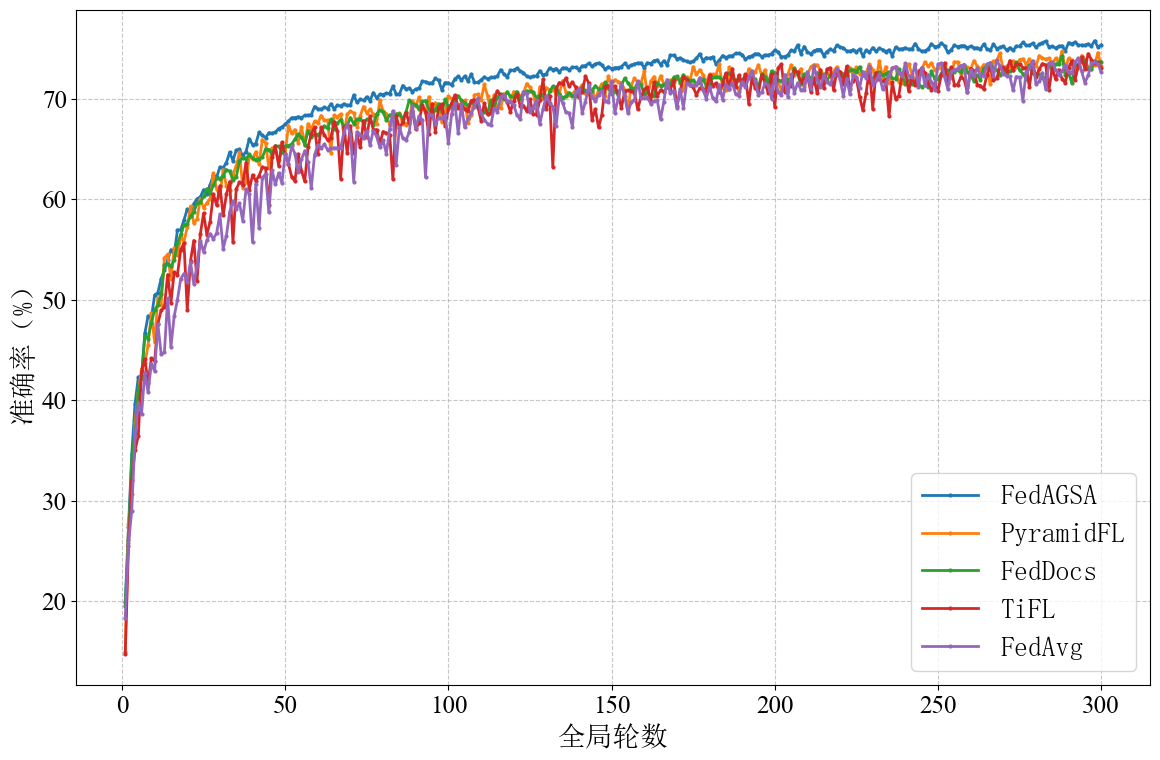

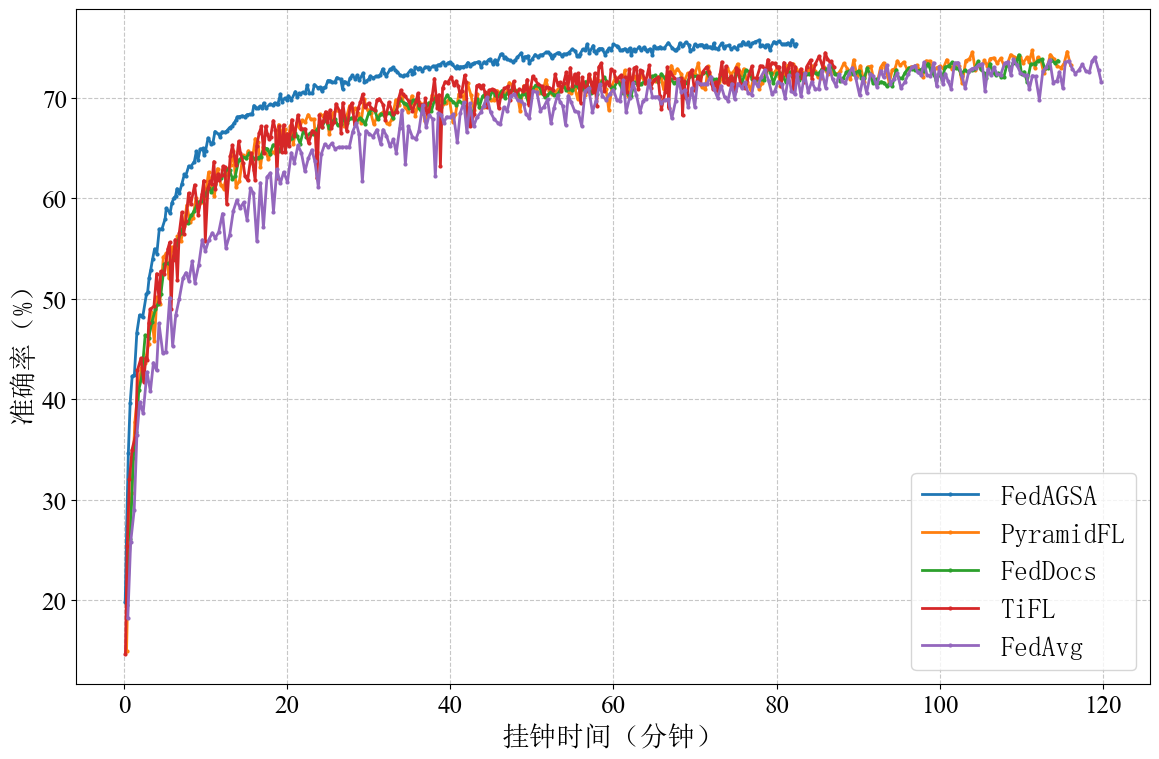

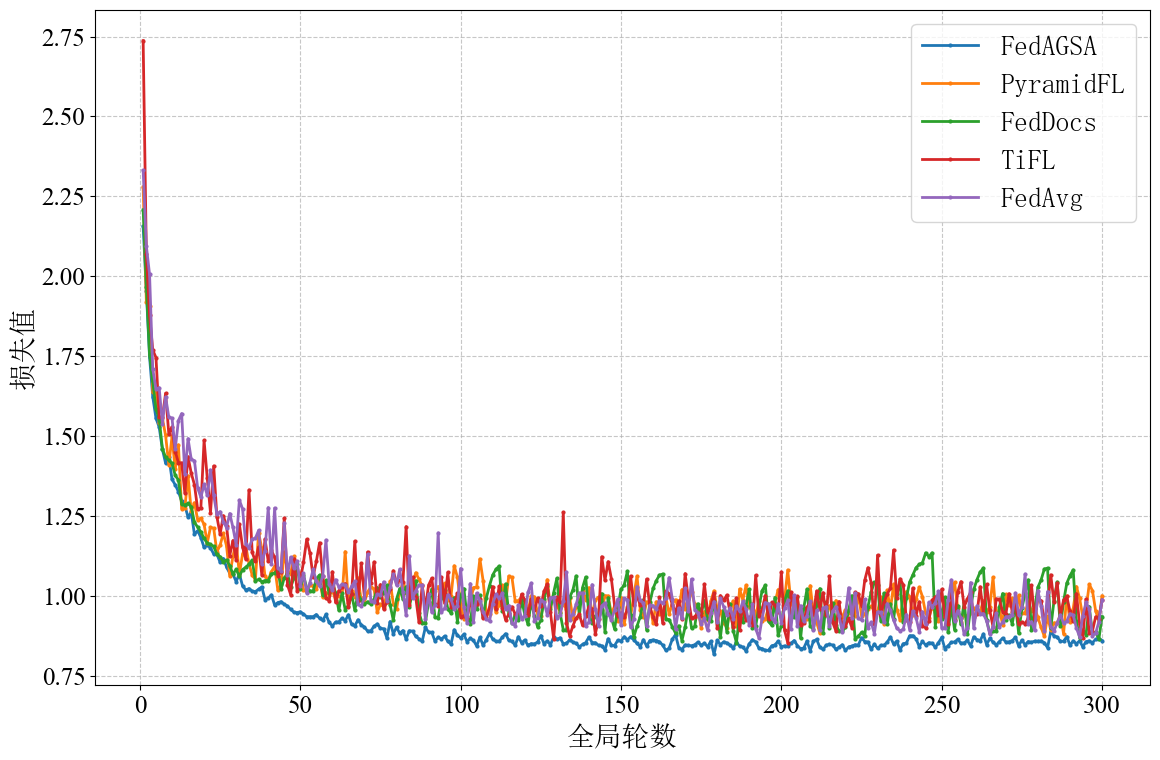

In [15]:

# 使用示例
if __name__ == "__main__":
    # 主目录路径
    main_dir = '/home/ypguo/async-FL/PK/Exp2025-Cifar10-lr0.5-Dir0.5'
    
    # 调用函数生成图表
    result = plot_federated_learning_performance(
        main_dir=main_dir,
        max_time=120,  # 60分钟
        total_rounds=300,
        save_epoch_plot=True,
        save_time_plot=True,
        fig_size=(12, 8),
        dpi=150,
        dataset_name="Cifar10",
        dir_alpha="0.5"
    )
    
    # 输出加载情况总结
    print(f"\n成功加载的算法: {len(result['loaded_algorithms'])}")
    print(f"跳过的算法: {len(result['skipped_algorithms'])}")
    